# Caso de prueba 1: Prediccion de Calidad del Vino

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from ucimlrepo import fetch_ucirepo

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [3]:
wine_quality = fetch_ucirepo(id=186)
wine_quality.data

{'ids': None,
 'features':       fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
 0               7.4              0.70         0.00             1.9      0.076   
 1               7.8              0.88         0.00             2.6      0.098   
 2               7.8              0.76         0.04             2.3      0.092   
 3              11.2              0.28         0.56             1.9      0.075   
 4               7.4              0.70         0.00             1.9      0.076   
 ...             ...               ...          ...             ...        ...   
 6492            6.2              0.21         0.29             1.6      0.039   
 6493            6.6              0.32         0.36             8.0      0.047   
 6494            6.5              0.24         0.19             1.2      0.041   
 6495            5.5              0.29         0.30             1.1      0.022   
 6496            6.0              0.21         0.38             0.8     

## Data Loading

### Datos en formato Dataframe

In [4]:
X = wine_quality.data.features
y = wine_quality.data.targets

df_wine = pd.concat([X, y], axis=1)
print(df_wine.head())

   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

## Visualazacion de los datos

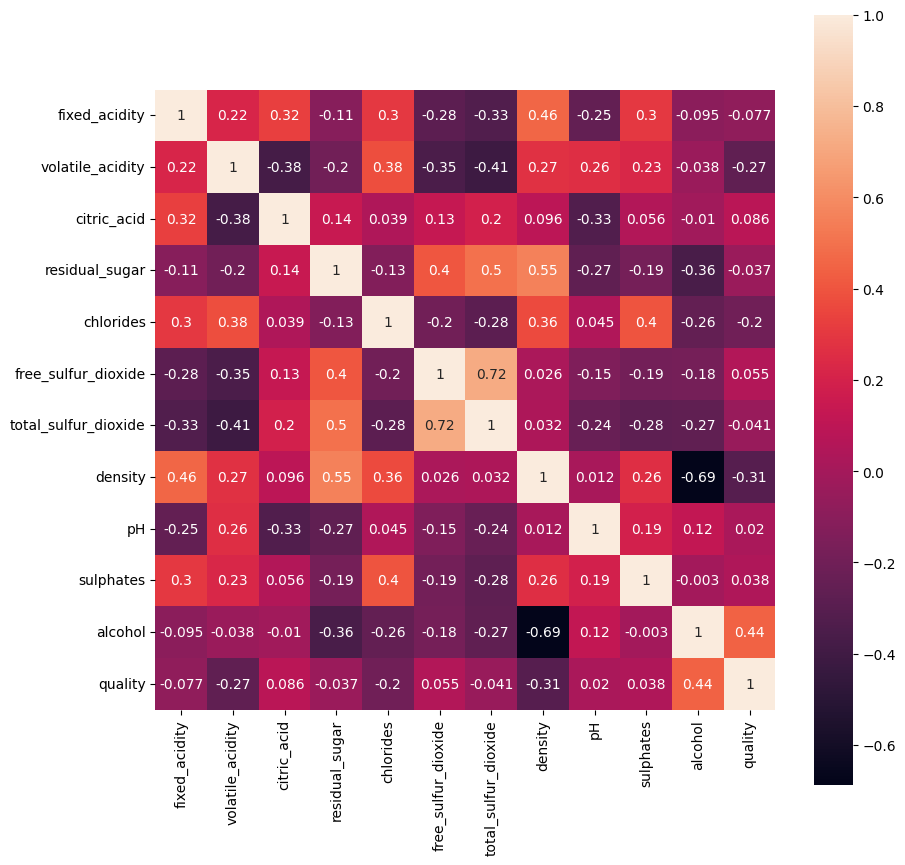

In [5]:
import seaborn as sns
plt.figure(figsize= (10,10))
sns.heatmap(df_wine.corr(), square=True, annot=True)
plt.show()

#### Seleccion de features

Debido que en ambito general hay poca correlaciones entre si, lo que da a deducir que la calidad sea mas bien un conjunto de todas ellas.
Por ello, por ahora selecciono las que tengan mas realcion con quality

In [6]:
feature_selection = ["alcohol", "density", "volatile_acidity", "chlorides"]

## Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(df_wine[feature_selection], df_wine["quality"], test_size=0.2 ,random_state=42)

## Knn como algoritmo de clasificacion

Para usar knn primero escalamos los datos

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)
(model.predict(X_test_scaled) == y_test).sum()

np.int64(669)